### Architecture 
In this experiment, FiLM-based fusion is applied by inserting the conditioning from metadata/tabular data to the EfficientNet internal features. The tabular features are first encoded with a small MLP to produce a conditioning vector, which dynamically generates per-channel FiLM parameters modulate the intermediate feature maps through dedicated FiLM layers. These FiLM-modulated visual features are then passed passed to the next block. Specifically in this experiment, FiLM is applied after stage 4 and its output linked to stage 5.the flow is like

image->EfficientBackBoneInner[Stage1->Stage2->Stage3->Stage4->x_med->gamma*x_med+beta->stage5toStage6...uptoHead]

 However, generally we can apply this FiLM after any stage as well as on more than one stage. 

<br>
<br>

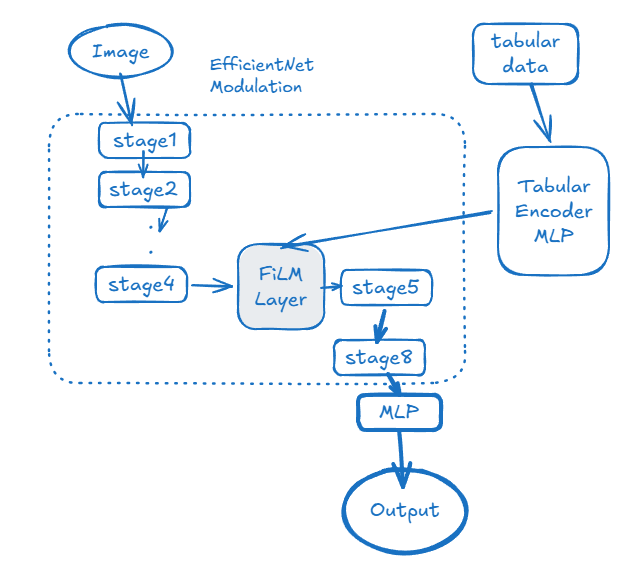



In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
sys.path.insert(0, os.path.abspath(".."))

In [41]:
# Cell 1: imports & setup
import os, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gc

gc.enable()

import torch


from src.config import EXP_CONFIGS
from src.utils import set_seed, save_config




main_folder = ".."
data_csv = os.path.join(main_folder, "data", "train.csv")
img_folder = os.path.join(main_folder, "data", "train")
out_dir = os.path.join(main_folder, "outputs", "exp12_film_fusion_effB1_internal_single_modulation")

df = pd.read_csv(data_csv)
cfg = EXP_CONFIGS["exp12_film"]   # define in config
cfg["name"] = "exp12_film_fusion_effB1_internal_single_modulation"
TARGET = "Pawpularity"
tab_cols = [c for c in df.columns if c not in ["Id", TARGET]]

os.makedirs(out_dir, exist_ok=True)
save_config(cfg, out_dir)
set_seed(cfg["seed"])
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [ ]:
from sklearn.model_selection import KFold
from sklearn.metrics import root_mean_squared_error
from src.train import run_single_fold

kf = KFold(n_splits=cfg["n_splits"], shuffle=True, random_state=cfg["seed"])
oof_pred = np.zeros(len(df))
oof_true = df[TARGET].values
fold_index = np.full(len(df), -1, dtype=int)
fold_rmse = []

start_all = time.time()
for fold, (tr_idx, val_idx) in enumerate(kf.split(df), start=1):
    print(f"\n=== {cfg['name']}: Fold {fold} ===")
    train_df = df.iloc[tr_idx].reset_index(drop=True)
    val_df   = df.iloc[val_idx].reset_index(drop=True)

    best_rmse, val_preds, val_targets, val_ids = run_single_fold(
    fold=fold,
    train_df=train_df,
    val_df=val_df,
    img_folder=img_folder,
    cfg=cfg,
    out_dir=out_dir,
    device=device,
    mode="film_fusion",   
    tab_cols=tab_cols,
    workers=16,
    pin_memory=True,
    persistent_workers=True,
    ##film related parameter
    film_start_idx=4,                   # to update the backbone block number
    apply_to_all_after=False,            # True: apply FiLM toall blocks >= idx, False: only at idx, so here we only apply FiLM at 4th stage/block of EfficientNet
    use_bn_affine=False,                # False => BN used but only normalizes values and doest not apply affine transformation(gamma & beta), instead FiLM applies affine transformation
)

    oof_pred[val_idx] = val_preds
    fold_index[val_idx] = fold
    fold_rmse.append(best_rmse)
    print(f"Fold {fold} best RMSE: {best_rmse:.4f}")

all_sec = time.time() - start_all
print(f"\nTotal training time: {int(all_sec//60)}m {int(all_sec%60)}s")
# final metrics + OOF with fold column
oof_rmse = root_mean_squared_error(oof_true, oof_pred)
fold_rmse = np.array(fold_rmse)
print(f"\nOOF RMSE: {oof_rmse:.4f}")
print(f"Fold RMSEs: {fold_rmse.tolist()}  Mean={fold_rmse.mean():.4f}  Std={fold_rmse.std():.4f}")

oof_df = pd.DataFrame({
    "Id": df["Id"],
    "fold": fold_index,     
    "ytrue": oof_true,
    "oof_pred": oof_pred,
})
oof_df["abs_err"] = (oof_df["ytrue"] - oof_df["oof_pred"]).abs()
oof_df.to_csv(os.path.join(out_dir, "oof_detail.csv"), index=False)
oof_df.sort_values("abs_err", ascending=False).head(50).to_csv(
    os.path.join(out_dir, "top50_errors.csv"), index=False
)

np.save(os.path.join(out_dir, "oof_pred.npy"), oof_pred)
np.save(os.path.join(out_dir, "fold_rmse.npy"), fold_rmse)
with open(os.path.join(out_dir, "metrics.txt"), "w") as f:
    f.write(f"OOF_RMSE: {oof_rmse:.4f}\n")
    f.write(f"Fold_RMSE: {fold_rmse.tolist()}\nMean: {fold_rmse.mean():.4f}\nStd: {fold_rmse.std():.4f}\n")



=== exp12_film_fusion_effB1_internal_single_modulation: Fold 1 ===
Epoch 1/10 | Fold 1 | Train[MSE]: RMSE=39.4794 | ValRMSE: 33.6745
Epoch 2/10 | Fold 1 | Train[MSE]: RMSE=29.0831 | ValRMSE: 24.7203
Epoch 3/10 | Fold 1 | Train[MSE]: RMSE=21.3170 | ValRMSE: 20.5611
Epoch 4/10 | Fold 1 | Train[MSE]: RMSE=17.1769 | ValRMSE: 20.7322
Epoch 5/10 | Fold 1 | Train[MSE]: RMSE=15.1175 | ValRMSE: 21.0976
Epoch 6/10 | Fold 1 | Train[MSE]: RMSE=13.1288 | ValRMSE: 21.1651
Epoch 7/10 | Fold 1 | Train[MSE]: RMSE=11.9253 | ValRMSE: 20.9774
Epoch 8/10 | Fold 1 | Train[MSE]: RMSE=10.7090 | ValRMSE: 21.2867
Early stopping at epoch 8
Fold 1 best RMSE: 20.5611

=== exp12_film_fusion_effB1_internal_single_modulation: Fold 2 ===
Epoch 1/10 | Fold 2 | Train[MSE]: RMSE=39.0162 | ValRMSE: 29.7996
Epoch 2/10 | Fold 2 | Train[MSE]: RMSE=27.1893 | ValRMSE: 22.9506
Epoch 3/10 | Fold 2 | Train[MSE]: RMSE=19.3023 | ValRMSE: 20.1285
Epoch 4/10 | Fold 2 | Train[MSE]: RMSE=15.8079 | ValRMSE: 21.1099
Epoch 5/10 | Fold 2 

In [7]:
#oof rmse = 20.68
import pandas as pd
df = pd.read_csv(out_dir+"/oof_detail.csv")
fold_rmse = []

for fold in range(1, 6):
    sub = df[df.fold == fold]
    rmse = ((sub.ytrue - sub.oof_pred)**2).mean() ** 0.5
    fold_rmse.append(rmse)
    print(f"Fold {fold} OOF RMSE: {rmse:.4f} (n={len(sub)})")

Fold 1 OOF RMSE: 20.5611 (n=1983)
Fold 2 OOF RMSE: 20.1285 (n=1983)
Fold 3 OOF RMSE: 19.6094 (n=1982)
Fold 4 OOF RMSE: 20.4656 (n=1982)
Fold 5 OOF RMSE: 20.6579 (n=1982)


### Train and Validation RMSE Curve

> when FiLM applied to EfficientNetB1 internal features of stage 4, the training and validation curve shows that the model did not perform well on the validation data and converges in very early epochs(3 to 5) indicating that the model learn useful patterns from the data within the first few epochs and begins memorizing the training images without gaining any additional generalization ability.

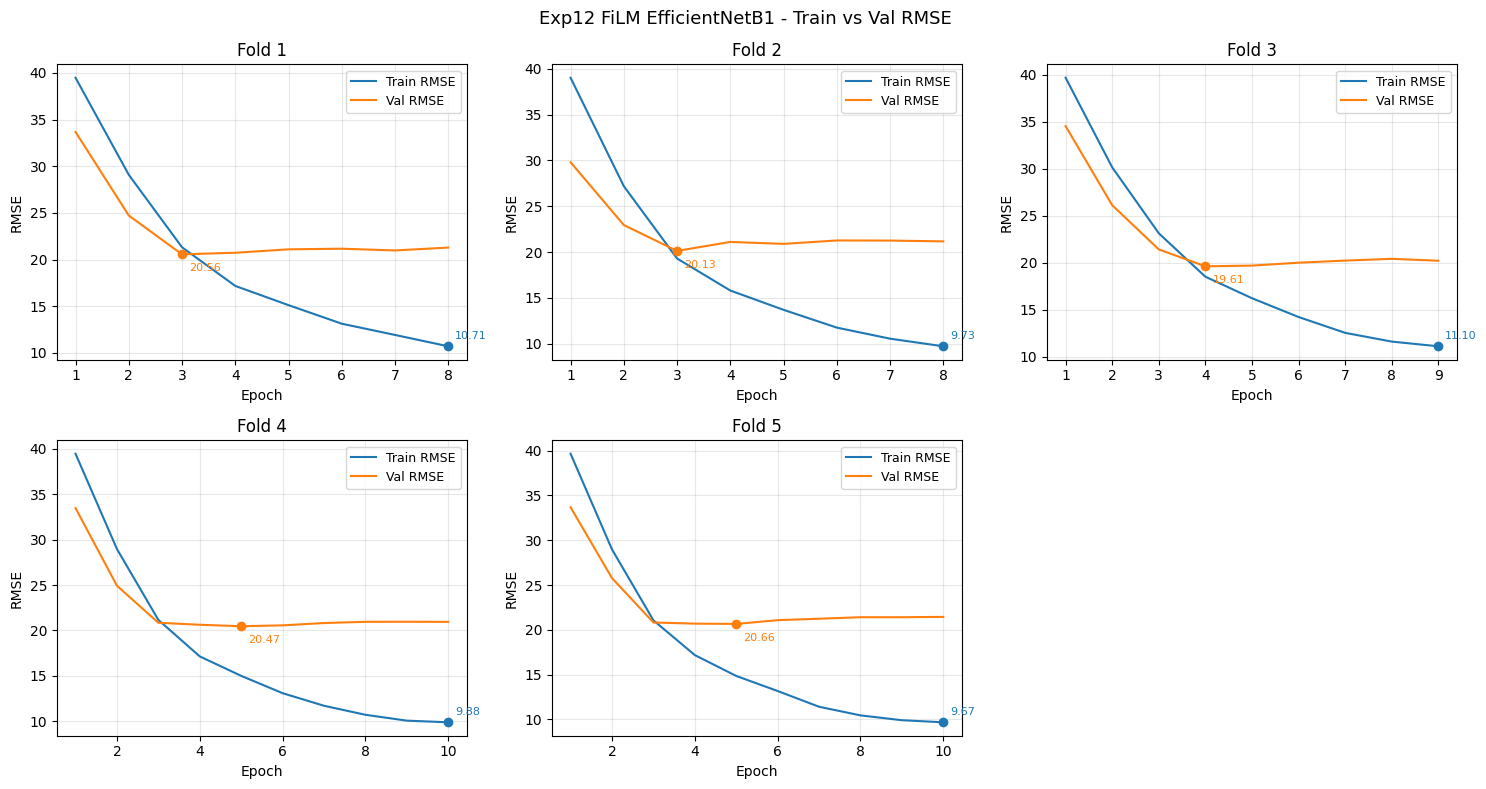

In [44]:
from src.plot import plot_train_val_history
plot_train_val_history(out_dir, folds=[1,2,3,4,5], title_prefix="Exp12 FiLM EfficientNetB1")

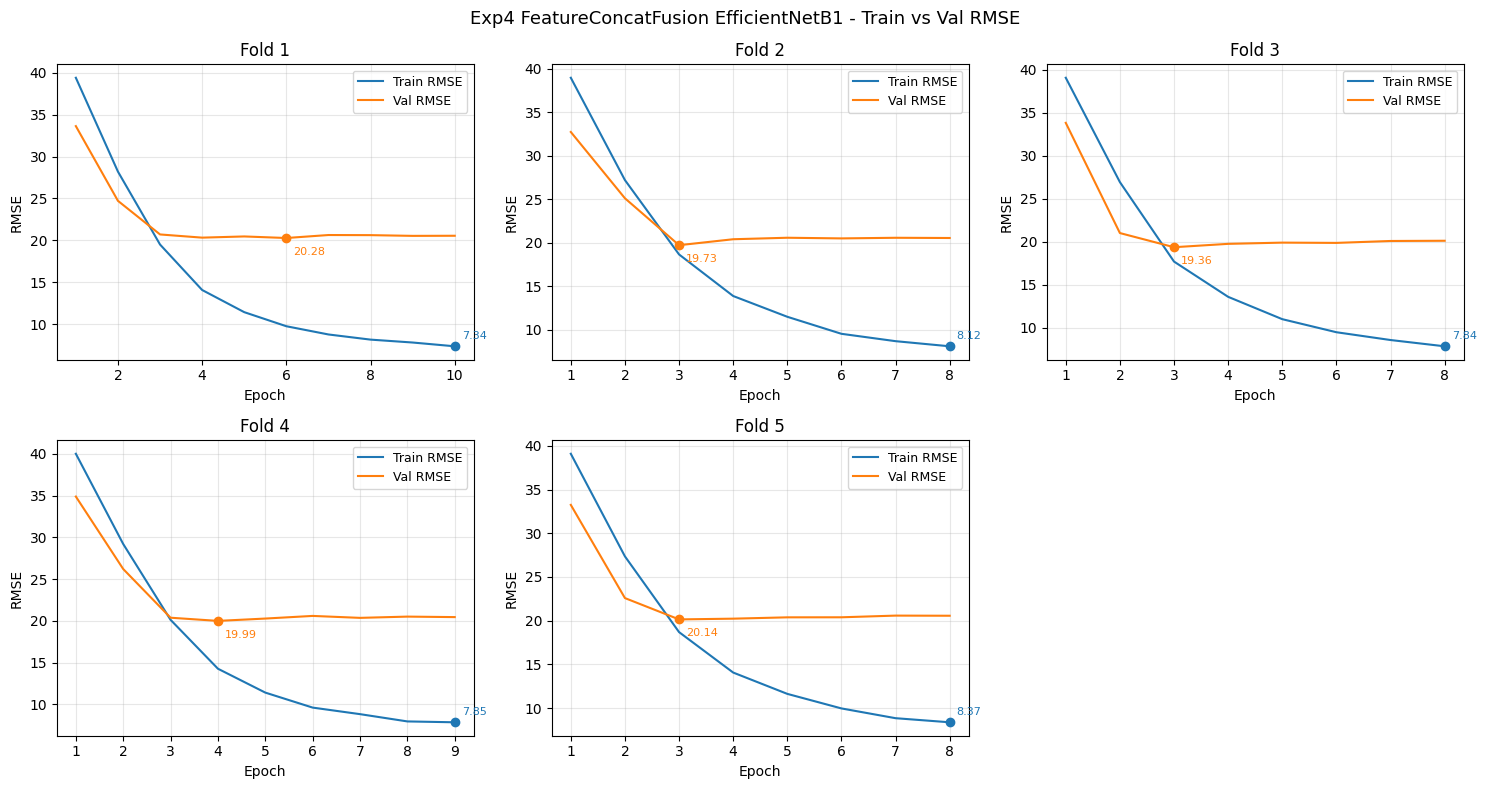

In [49]:
from src.plot import plot_train_val_history
out_dir1 = os.path.join("..", "outputs", "exp4")
plot_train_val_history(out_dir1, folds=[1,2,3,4,5], title_prefix="Exp4 FeatureConcatFusion EfficientNetB1")

### Side by Side Comparison with Concatenation based Feature Fusion Exp4

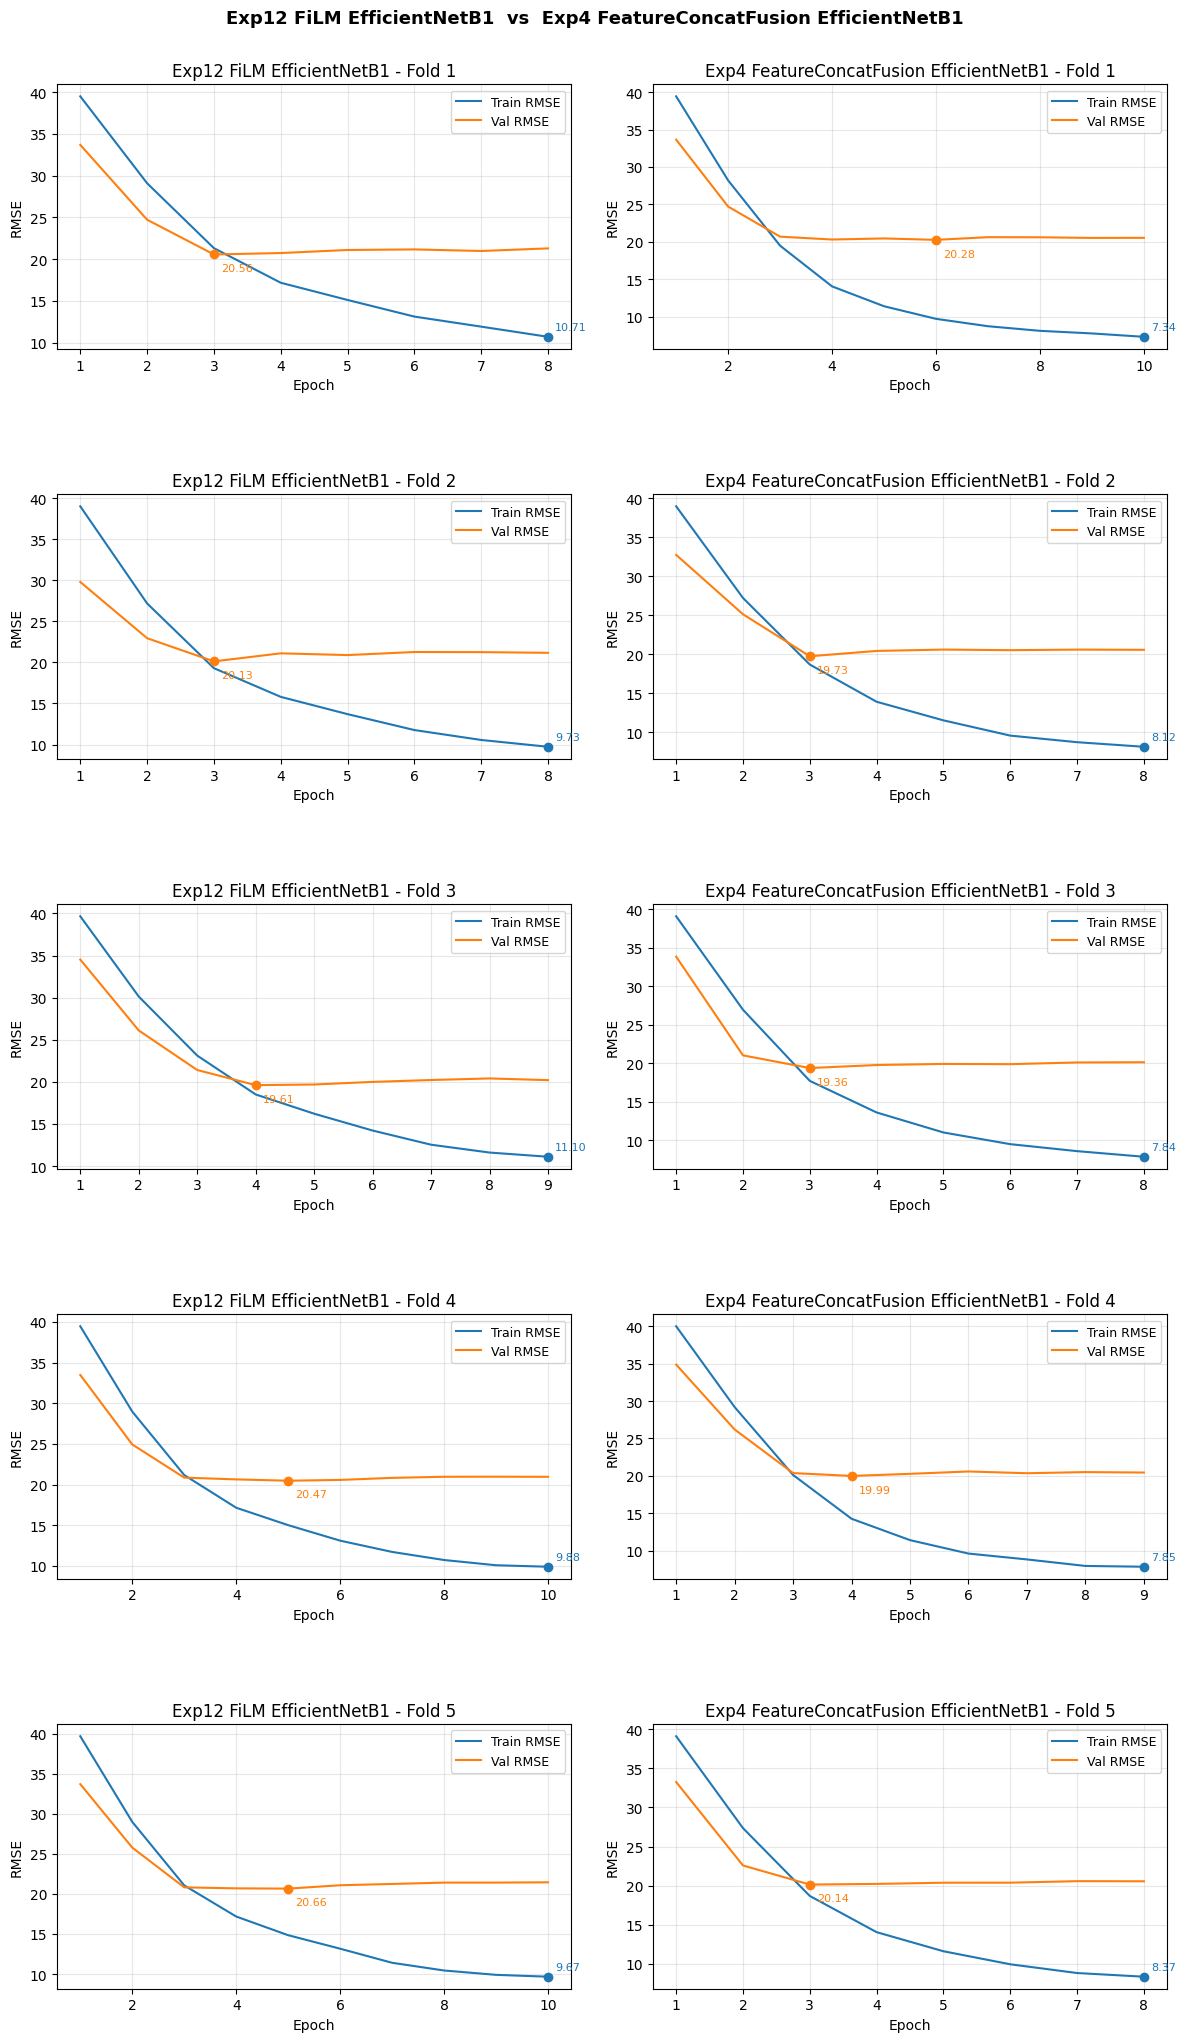

In [48]:
from src.plot import plot_compare_two_experiments
plot_compare_two_experiments(out_dir, out_dir1,folds=[1,2,3,4,5], label_a="Exp12 FiLM EfficientNetB1", label_b="Exp4 FeatureConcatFusion EfficientNetB1")

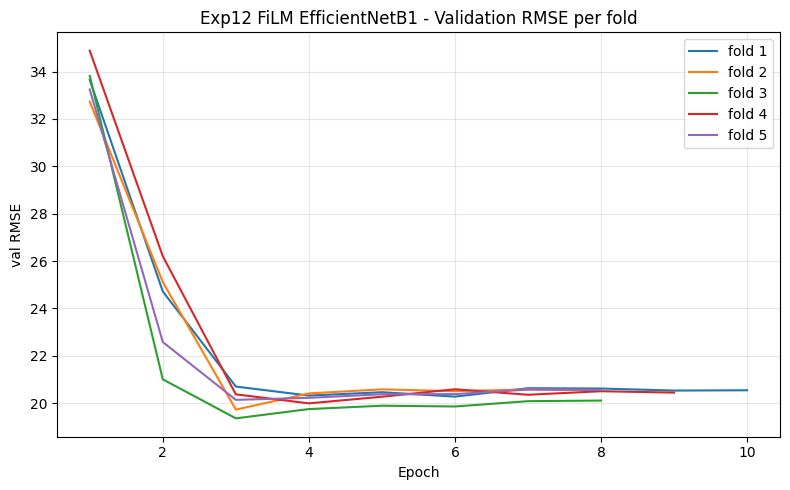

In [38]:
from src.plot import plot_all_folds_history
plot_all_folds_history(out_dir, folds=[1,2,3,4,5], title_prefix="Exp12 FiLM EfficientNetB1")

In [50]:
#  Inspect worst error rows

errors_path = os.path.join(out_dir, "top50_errors.csv")
err_df = pd.read_csv(errors_path)
err_df.head()

,Id,fold,ytrue,oof_pred,abs_err
0,ab86addb09d3ccbe620f9e68889bb7d6,1,100,3.022678,96.977322
1,a1c4da5842d088af2d04ba70b1388397,1,85,2.608348,82.391652
2,deb8d1618d0cdc2a78c8198b882ebb2b,3,100,20.170158,79.829842
3,3d69187b44aba9adbd7fd5f0d3554cd1,5,7,86.751320,79.751320
4,6ffbae72a33918217eb05e6c9fac05be,3,12,90.893570,78.893570


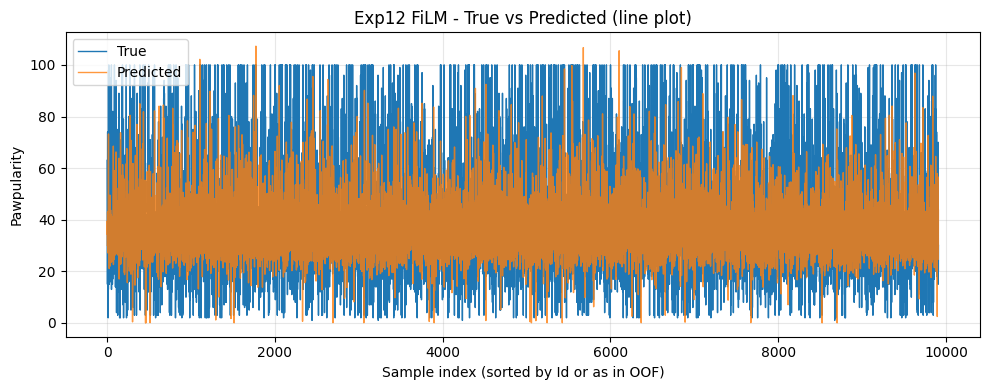

In [59]:
import os
import pandas as pd
from src.plot import (
   plot_oof_true_pred_lines,
    show_images_grid,
)

# Load OOF detail and top-errors
oof_df = pd.read_csv(os.path.join(out_dir, "oof_detail.csv"))
err_df = pd.read_csv(os.path.join(out_dir, "top50_errors.csv"))

# Plot
plot_oof_true_pred_lines(oof_df, title_prefix="Exp12 FiLM")





Exp12_FiLM_Eff_B1 Fusion OOF RMSE: 20.28812059634458
Exp4_FeatureConcat EffB1 Fusion OOF RMSE: 19.90331621767278
ΔRMSE (Exp4_FeatureConcat EffB1 Fusion - Exp12_FiLM_Eff_B1 Fusion): -0.38480437867179873


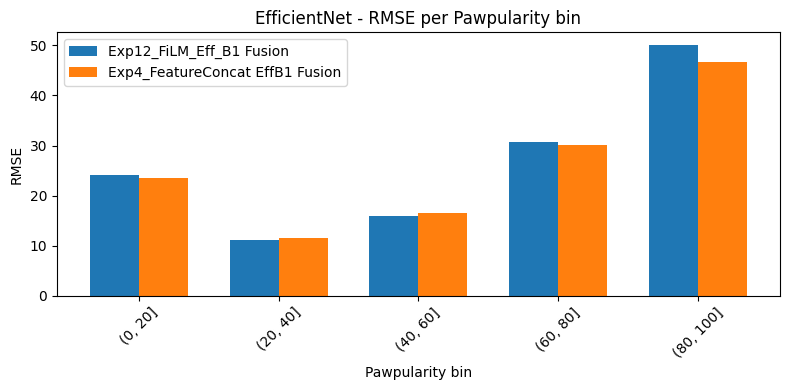

In [56]:
from src.plot import compare_oof_by_bins
bins = [0, 20, 40, 60, 80, 100]

df_bins, rmse3_all, rmse5_all, gap = compare_oof_by_bins(
    oof_path_a=os.path.join(out_dir, "oof_detail.csv"),
    oof_path_b=os.path.join(out_dir1, "oof_detail.csv"),
    bins=bins,
    label_a="Exp12_FiLM_Eff_B1 Fusion",
    label_b="Exp4_FeatureConcat EffB1 Fusion",
    title_prefix="EfficientNet",
)

In [57]:
df_bins.head()

,bin,count,Exp12_FiLM_Eff_B1 Fusion_rmse,Exp4_FeatureConcat EffB1 Fusion_rmse,rmse_diff,winner
0,"(0, 20]",1417,24.067272,23.561754,-0.505518,Exp4_FeatureConcat EffB1 Fusion_better
1,"(20, 40]",5119,11.188082,11.605182,0.417099,Exp12_FiLM_Eff_B1 Fusion_better
2,"(40, 60]",2088,15.887710,16.538259,0.650550,Exp12_FiLM_Eff_B1 Fusion_better
3,"(60, 80]",727,30.660238,30.127592,-0.532646,Exp4_FeatureConcat EffB1 Fusion_better
4,"(80, 100]",561,50.095334,46.623998,-3.471335,Exp4_FeatureConcat EffB1 Fusion_better


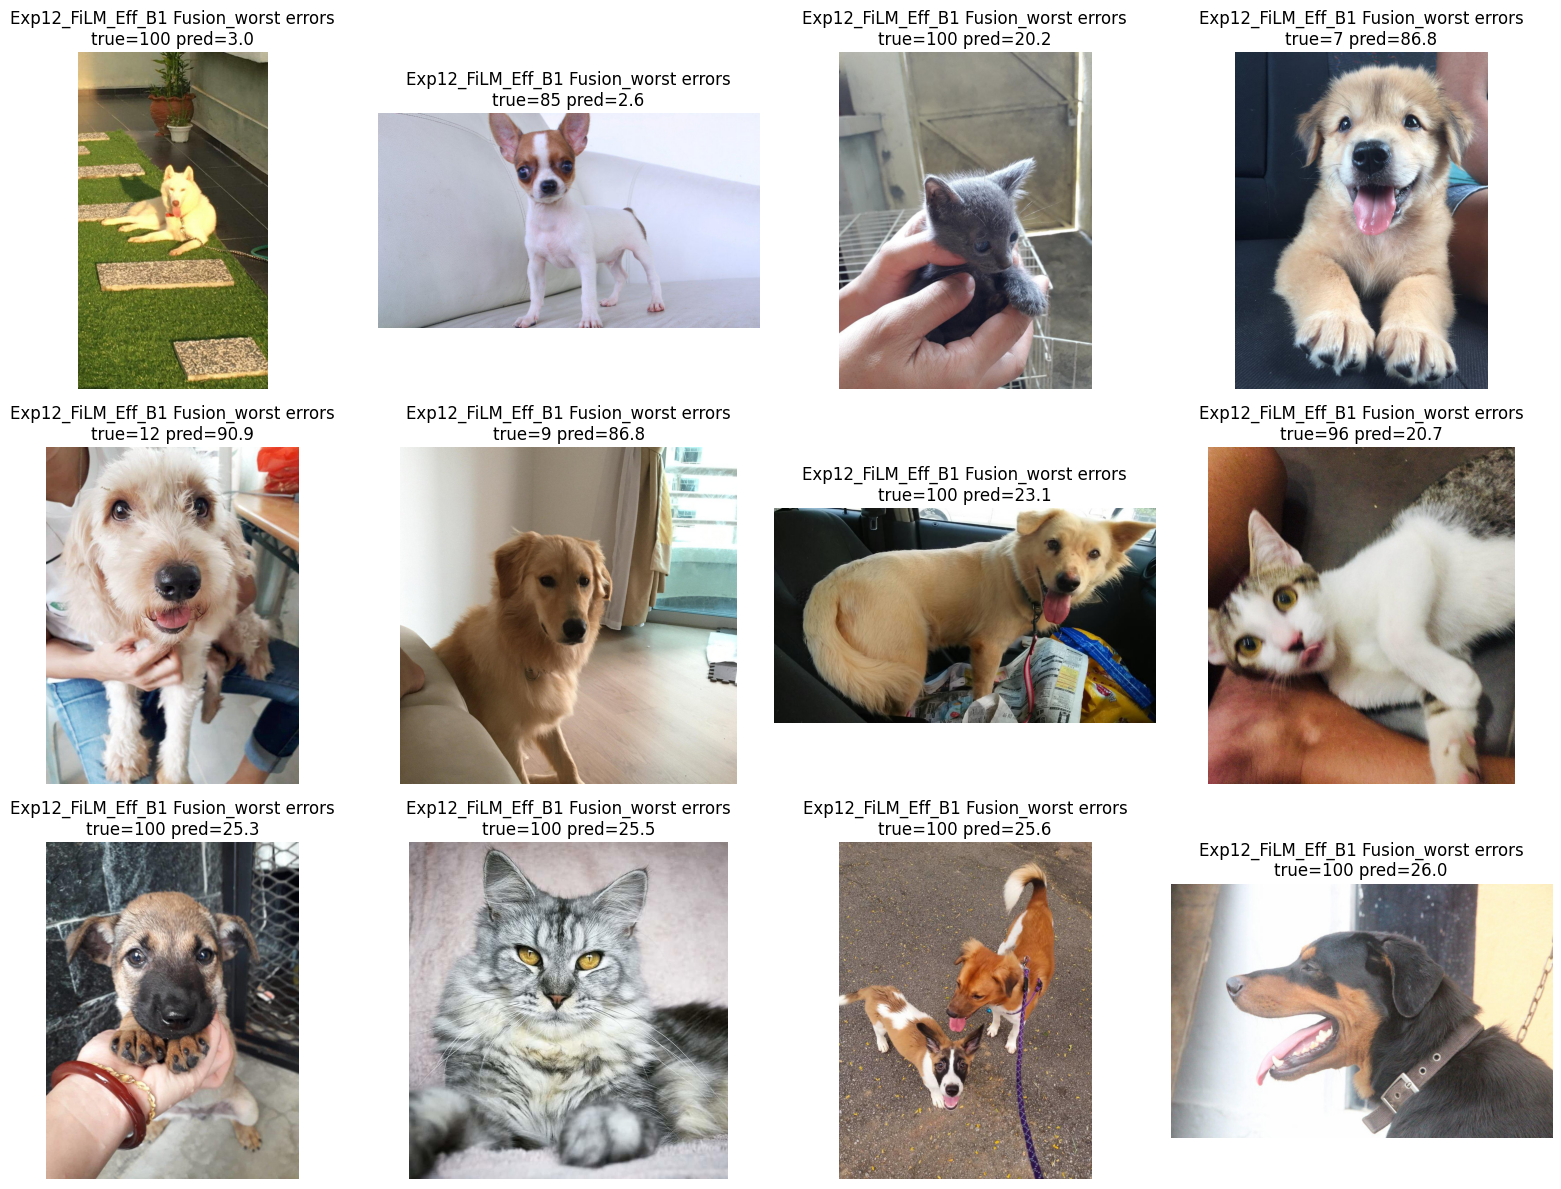

In [ ]:
# Images of worst errors of FiLM 12 experiment
img_folder = os.path.join(main_folder, "data", "train")
show_images_grid(err_df, img_folder, n=12, title_prefix="Exp12_FiLM_Eff_B1 Fusion_worst errors")

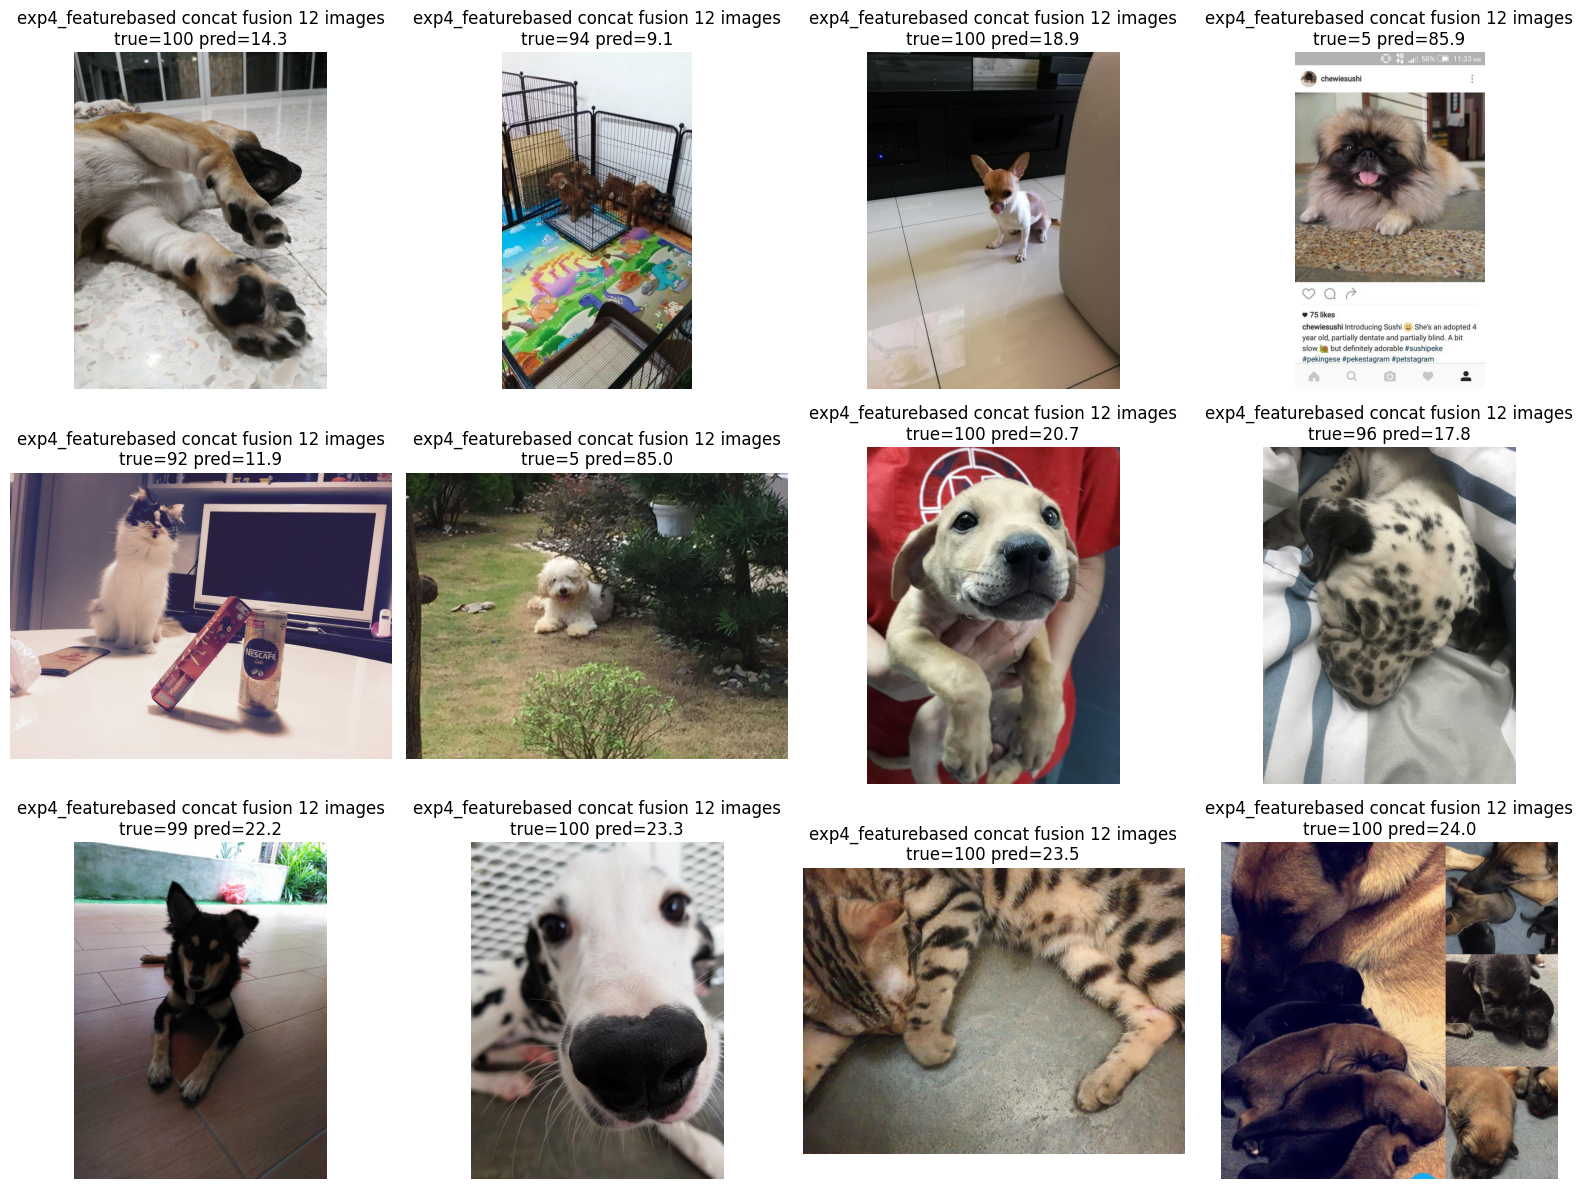

In [ ]:

# Load OOF detail and top-errors of Exp4 
oof_df1 = pd.read_csv(os.path.join(out_dir1, "oof_detail.csv"))
err_df1 = pd.read_csv(os.path.join(out_dir1, "top50_errors.csv"))
show_images_grid(err_df1, img_folder, n=12, title_prefix="exp4_featurebased concat fusion 12 images")